In [1]:
# Charger via pandas jena_filtered dans un df
# Mettre dans la serie temp la colonne des temperatures
# Afficher les temperatures min, max, mean, std
# Afficher les temperatures dans un plot matplotlib
# Calculer la mean des températures de la 1ère année .values[:365*24] et de la dernière année
# Filtrer le dataframe en prenant que les températures à midi
# Sauvegarder le dataframe en excel

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [3]:
df = pd.read_csv("data/jena/jena_filtered.csv") #, index_col="id")
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.40,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
1,01.01.2009 02:00:00,996.62,-8.88,264.54,-9.77,93.20,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2,01.01.2009 03:00:00,996.84,-8.81,264.59,-9.66,93.50,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
3,01.01.2009 04:00:00,996.99,-9.05,264.34,-10.02,92.60,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
4,01.01.2009 05:00:00,997.46,-9.63,263.72,-10.65,92.20,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70070,31.12.2016 19:50:00,1001.55,-1.65,271.39,-6.55,69.05,5.41,3.74,1.67,2.32,3.73,1283.24,0.73,1.20,212.0
70071,31.12.2016 20:50:00,1001.33,-3.46,269.59,-7.13,75.60,4.73,3.57,1.15,2.22,3.57,1291.65,0.81,1.16,201.4
70072,31.12.2016 21:50:00,1000.81,-2.48,270.62,-6.95,71.20,5.09,3.62,1.47,2.25,3.62,1286.24,0.24,0.52,9.4
70073,31.12.2016 22:50:00,1000.32,-4.09,269.05,-7.23,78.60,4.51,3.54,0.96,2.21,3.54,1293.37,1.25,1.60,199.2


In [4]:
temp = df["T (degC)"]
temp

0       -8.05
1       -8.88
2       -8.81
3       -9.05
4       -9.63
         ... 
70070   -1.65
70071   -3.46
70072   -2.48
70073   -4.09
70074   -4.23
Name: T (degC), Length: 70075, dtype: float64

In [5]:
temp.describe()

count    70075.000000
mean         9.448744
std          8.424157
min        -22.760000
25%          3.355000
50%          9.410000
75%         15.480000
max         37.280000
Name: T (degC), dtype: float64

In [6]:
np.mean(temp), temp.mean(), temp.values.mean()

(np.float64(9.448744202640029),
 np.float64(9.448744202640029),
 np.float64(9.448744202640029))

In [7]:
window = 24
weights = np.ones(window) / window
temp_avg = np.convolve(temp, weights, mode='valid')
temp_avg

array([-6.75833333, -6.60791667, -6.41666667, ..., -2.44333333,
       -2.49708333, -2.50583333], shape=(70052,))

In [8]:
df = df[11::24]
temp = df["T (degC)"]
temp

11      -6.87
35      -3.12
59      -5.96
83      -1.21
107     -3.65
         ... 
69971    5.86
69995    4.53
70019    4.06
70043    2.26
70067    1.61
Name: T (degC), Length: 2920, dtype: float64

In [20]:
x = np.arange(len(temp))
slope, intercept, rvalue, pvalue, stderr = stats.linregress(x, temp)
slope, intercept, rvalue, pvalue, stderr, len(x)

(np.float64(0.0007291881238974344),
 np.float64(10.262585549610051),
 np.float64(0.07046470199594752),
 np.float64(0.00013851224250310693),
 np.float64(0.00019109285199579368),
 2920)

0.26615366522256356


<module 'matplotlib.pyplot' from 'C:\\Users\\conta\\git-CVC\\Formation\\Python\\DataScience\\gitdatascience\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

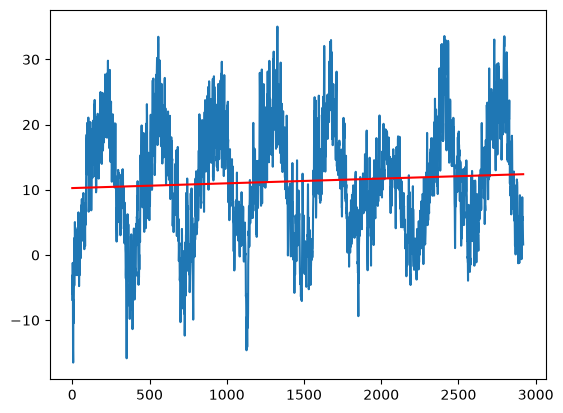

In [21]:
plt.plot(x, temp)
plt.plot(x, slope * x + intercept, color="red")
print(slope * 365)
plt

In [11]:
np.mean(temp[:365])

np.float64(11.041753424657536)

In [12]:
np.mean(temp[:-365])

np.float64(11.094716242661448)

In [13]:
df.to_excel("data/jena/jena.xlsx", index=None) # pip install openpyxl

In [14]:
np.inf + 1

inf

In [15]:
v1 = np.array([1,2,3,np.inf])
v1.mean()

np.float64(inf)

In [16]:
vnan = np.array([1,2,3,np.nan])
vnan.mean(), np.nanmean(vnan)

(np.float64(nan), np.float64(2.0))

In [17]:
temp.mean() # <=> temp.values.nanmean()

np.float64(11.326835616438357)

In [18]:
fft = np.fft.fft(temp)
x = np.arange(len(fft))

<module 'matplotlib.pyplot' from 'C:\\Users\\conta\\git-CVC\\Formation\\Python\\DataScience\\gitdatascience\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

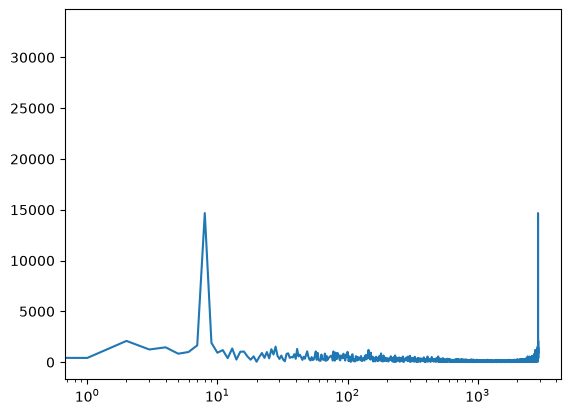

In [19]:
plt.plot(x, np.abs(fft))
plt.xscale('log')
plt